<a href="https://colab.research.google.com/github/parasssssss/trader-sentiment-analysis/blob/main/notebook/Primetrade_ai_round_0_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A — Data preparation (must-have)

In [1]:
import pandas as pd

trades = pd.read_csv("/historical_data - historical_data.csv")
sentiment = pd.read_csv("/fear_greed_index - fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

print("\nTrades columns:\n", trades.columns)
print("\nSentiment columns:\n", sentiment.columns)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)

Trades columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


- Trades dataset has 211224 rows and 16 columns
- Sentiment dataset has 2644 rows and 4 columns

In [2]:
print("\nMissing values in trades:\n", trades.isnull().sum())
print("\nMissing values in sentiment:\n", sentiment.isnull().sum())


Missing values in trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64


- Trades dataset has no NULL values
- Sentiment dataset has no NULL values

In [3]:
print("Duplicate rows in trades:", trades.duplicated().sum())
print("Duplicate rows in sentiment:", sentiment.duplicated().sum())

Duplicate rows in trades: 0
Duplicate rows in sentiment: 0


- Trades dataset has no DUPLICATE values
- Sentiment dataset has no DUPLICATE values

In [5]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [6]:
daily_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
trade_count = trades.groupby(['Account','date']).size().reset_index(name='trades')
avg_size = trades.groupby(['Account','date'])['Size USD'].mean().reset_index(name='avg_size')
trades['win'] = trades['Closed PnL'] > 0
win_rate = trades.groupby(['Account','date'])['win'].mean().reset_index(name='win_rate')
long_trades = trades[trades['Side'] == 'BUY'].groupby(['Account','date']).size()
short_trades = trades[trades['Side'] == 'SELL'].groupby(['Account','date']).size()
ratio = (long_trades / short_trades).reset_index(name='long_short_ratio')
df = daily_pnl.merge(trade_count, on=['Account','date'])
df = df.merge(avg_size, on=['Account','date'])
df = df.merge(win_rate, on=['Account','date'])
df = df.merge(ratio, on=['Account','date'], how='left')
final_df = df.merge(sentiment[['date','classification']], on='date', how='left')

### Data Preparation Summary

- Converted timestamps to daily level
- Created key metrics:
  - Daily PnL
  - Trade frequency
  - Average trade size
  - Win rate
  - Long/Short ratio
- Merged trader data with market sentiment dataset

#Part B — Analysis (must-have)

In [7]:
perf = final_df.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win_rate': 'mean'
}).reset_index()

print(perf)

  classification   Closed PnL  win_rate
0   Extreme Fear  4619.439053  0.329659
1  Extreme Greed  5161.922644  0.386387
2           Fear  5328.818161  0.364033
3          Greed  3318.100730  0.343559
4        Neutral  3438.618818  0.355414


#Insights
- Traders achieve the highest average PnL and win rate during Extreme Greed periods. This suggests that strong bullish sentiment creates favorable conditions for profitable trading, likely due to sustained upward price movements and momentum.

- Interestingly, average PnL during Fear periods is also relatively high, even exceeding Extreme Greed in this dataset. This indicates that skilled traders may exploit market panic and volatility to generate profits, possibly through short positions or mean-reversion strategies.

- Win rates are highest during Extreme Greed and relatively lower during Extreme Fear, indicating that stronger sentiment (especially bullish) provides more consistent trade outcomes, while uncertain or fearful markets reduce predictability.



In [9]:
behavior = final_df.groupby('classification').agg({
    'trades': 'mean',
    'avg_size': 'mean',
    'long_short_ratio': 'mean'
}).reset_index()

print(behavior)

  classification      trades     avg_size  long_short_ratio
0   Extreme Fear  133.750000  6773.464125          3.268598
1  Extreme Greed   76.030418  5371.637182          1.903983
2           Fear   98.153968  8975.928546          2.831197
3          Greed   77.628086  6427.866594          2.513434
4        Neutral  100.228723  6963.694861          3.027277


### Insight 1: Higher Trading Activity During Fear
Traders execute the highest number of trades during Extreme Fear periods, indicating that market panic or volatility leads to increased trading activity.

### Insight 2: Larger Trade Sizes in Fear Markets
Average trade size is highest during Fear conditions, suggesting that traders take bigger positions to capitalize on uncertain and volatile price movements.

### Insight 3: Strong Long Bias During Fear
The long/short ratio peaks during Extreme Fear, showing that traders prefer taking long positions even in bearish conditions, possibly expecting price reversals.

### Insight 4: Lower Activity in Greed Periods
Trading frequency and position sizes are relatively lower during Greed periods, indicating more stable and less aggressive trading behavior.

In [30]:
final_df['trader_type'] = final_df['trades'].apply(
    lambda x: 'High' if x > final_df['trades'].median() else 'Low'
)

In [12]:
seg1 = final_df.groupby(['classification','trader_type'])['Closed PnL'].mean().reset_index()
print(seg1)

  classification trader_type    Closed PnL
0   Extreme Fear        High   6799.753651
1   Extreme Fear         Low    457.020275
2  Extreme Greed        High   8437.437459
3  Extreme Greed         Low   1627.473851
4           Fear        High  10311.492505
5           Fear         Low    913.034911
6          Greed        High   5486.377107
7          Greed         Low   1401.949513
8        Neutral        High   5759.162182
9        Neutral         Low   1118.075454


### Insight: Active Traders Benefit More from Market Volatility

- High-frequency traders outperform low-frequency traders in every sentiment category, with the highest gains observed during Fear and Extreme Greed periods.

- This indicates that frequent trading allows better capture of short-term opportunities, especially in volatile or high-momentum markets, while less active traders miss out on these opportunities.

In [13]:
final_df['performance_type'] = final_df['Closed PnL'].apply(
    lambda x: 'Winner' if x > 0 else 'Loser'
)

In [14]:
final_df['size_type'] = final_df['avg_size'].apply(
    lambda x: 'Large' if x > final_df['avg_size'].median() else 'Small'
)

In [20]:
final_df['long_short_ratio'] = final_df['long_short_ratio'].fillna(0)

In [36]:
print(final_df.head())

                                      Account        date  Closed PnL  trades  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0     177   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0      68   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0      40   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0      12   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1      27   

       avg_size  win_rate  long_short_ratio classification trader_type  \
0   5089.718249  0.000000               0.0  Extreme Greed        High   
1   7976.664412  0.000000               0.0  Extreme Greed        High   
2  23734.500000  0.000000               0.0  Extreme Greed        High   
3  28186.666667  0.000000               0.0  Extreme Greed         Low   
4  17248.148148  0.444444               0.8  Extreme Greed         Low   

  performance_type size_type  
0            Loser     Large  
1     

In [31]:
print(final_df.groupby('classification')[['Closed PnL','win_rate']].mean().sort_values(by='Closed PnL', ascending=False))

                 Closed PnL  win_rate
classification                       
Fear            5328.818161  0.364033
Extreme Greed   5161.922644  0.386387
Extreme Fear    4619.439053  0.329659
Neutral         3438.618818  0.355414
Greed           3318.100730  0.343559


### Insight 1: Highest Profitability During Fear Markets
Traders achieve the highest average PnL during Fear periods, indicating that volatile and uncertain market conditions provide strong profit opportunities for active traders.

### Insight 2: Strong Performance in Extreme Greed
Extreme Greed also shows high PnL along with the highest win rate, suggesting that strong bullish momentum leads to more consistent and profitable trades.

### Insight 3: Lower Profitability in Greed and Neutral Markets
Greed and Neutral conditions show relatively lower PnL, indicating that moderate or stable market sentiment offers fewer trading opportunities compared to extreme conditions.

### Insight 4: Win Rate Peaks in Extreme Greed
Win rate is highest during Extreme Greed, showing that traders are more consistently successful when the market trend is strongly positive.

In [32]:
print(final_df.groupby('classification')[['trades','avg_size','long_short_ratio']].mean())

                    trades     avg_size  long_short_ratio
classification                                           
Extreme Fear    133.750000  6773.464125          2.185875
Extreme Greed    76.030418  5371.637182          1.201754
Fear             98.153968  8975.928546          1.626815
Greed            77.628086  6427.866594          1.442897
Neutral         100.228723  6963.694861          1.900099


### Insight 1: Highest Trading Activity in Extreme Fear
Traders execute the most trades during Extreme Fear periods, indicating that high volatility and panic drive increased market participation.

### Insight 2: Larger Positions Taken During Fear
Average trade size is highest during Fear conditions, suggesting that traders take bigger positions to capitalize on uncertain and volatile price movements.

### Insight 3: Reduced Activity in Greed Markets
Trading frequency and position sizes are lower during Greed and Extreme Greed periods, indicating more stable and less aggressive trading behavior.

### Insight 4: Long Bias Across All Conditions
The long/short ratio remains above 1 in all sentiment categories, showing a consistent preference for long positions, though it is strongest during Extreme Fear.

In [33]:
print(final_df.groupby(['classification','trader_type'])['Closed PnL'].mean().unstack())

trader_type             High          Low
classification                           
Extreme Fear     6799.753651   457.020275
Extreme Greed    8437.437459  1627.473851
Fear            10311.492505   913.034911
Greed            5486.377107  1401.949513
Neutral          5759.162182  1118.075454


### Insight 1: High-Frequency Traders Consistently Outperform
High-frequency traders generate significantly higher average PnL compared to low-frequency traders across all market conditions.

### Insight 2: Maximum Advantage During Fear Markets
The performance gap is largest during Fear periods, where high-frequency traders earn substantially higher profits, indicating their ability to capitalize on volatility.

### Insight 3: Strong Gains in Extreme Greed for Active Traders
High-frequency traders also achieve very high profits during Extreme Greed, showing that active trading benefits from strong market trends.

### Insight 4: Low-Frequency Traders Show Limited Profitability
Low-frequency traders consistently earn much lower PnL across all sentiments, suggesting missed opportunities and less effective trading strategies.

In [34]:
print(final_df.groupby(['classification','performance_type'])['Closed PnL'].mean().unstack())

performance_type        Loser        Winner
classification                             
Extreme Fear     -7524.650313  12715.498631
Extreme Greed    -1353.654330   8192.845637
Fear             -1560.513241   9831.294590
Greed            -3417.662797   7604.495702
Neutral          -2034.764124   6760.073424


### Insight 1: Winners Generate Strong Profits Across All Market Conditions
Winning trades consistently produce high positive PnL across all sentiment categories, with the highest gains observed during Extreme Fear and Fear periods.

### Insight 2: Losses Are Highest During Extreme Fear
Losing trades show the largest negative PnL during Extreme Fear, indicating that volatile and uncertain markets increase downside risk.

### Insight 3: Favorable Risk-Reward in Fear Markets
Despite higher losses, Fear conditions also deliver the highest winning PnL, suggesting a high risk–high reward environment for traders.

### Insight 4: More Stable Outcomes in Greed Markets
Greed and Neutral conditions show relatively smaller losses and steady profits, indicating more stable but less extreme trading outcomes.

In [35]:
print(final_df.groupby(['classification','size_type'])['Closed PnL'].mean().unstack())

size_type             Large        Small
classification                          
Extreme Fear    8445.038316    60.163219
Extreme Greed   6505.194438  3734.367129
Fear            9871.490346  1172.756375
Greed           4312.582036  2260.276665
Neutral         6403.719647   829.330088


### Insight 1: Large Trades Generate Significantly Higher Profits
Across all sentiment conditions, large trades consistently produce much higher average PnL compared to small trades, indicating that position size plays a key role in profitability.

### Insight 2: Maximum Gains from Large Trades in Fear Markets
Large trades achieve the highest profits during Fear and Extreme Fear periods, suggesting that taking bigger positions during volatile markets can lead to substantial returns.

### Insight 3: Limited Profitability from Small Trades
Small trades generate relatively low PnL across all market conditions, indicating that conservative position sizing may limit profit potential.

### Insight 4: Higher Risk–Reward with Large Trades
While large trades yield higher profits, they are also likely associated with higher risk, especially in volatile market conditions like Fear.

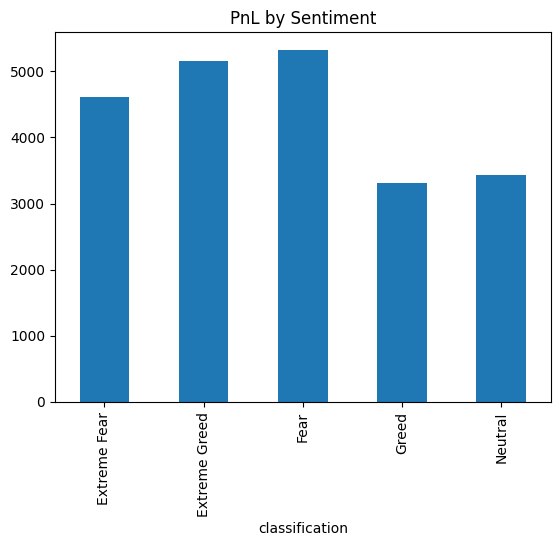

In [27]:
final_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL by Sentiment")
plt.show()

### Insight: Higher Profitability in Fear and Extreme Greed Conditions

- The chart shows that average PnL is highest during Fear and Extreme Greed periods, indicating that traders benefit most during highly volatile or strongly trending market conditions.

- In contrast, Greed and Neutral periods exhibit significantly lower PnL, suggesting fewer profitable opportunities when market sentiment is moderate or stable.

- This highlights that extreme market emotions (both fear and optimism) create better trading opportunities compared to balanced market conditions.

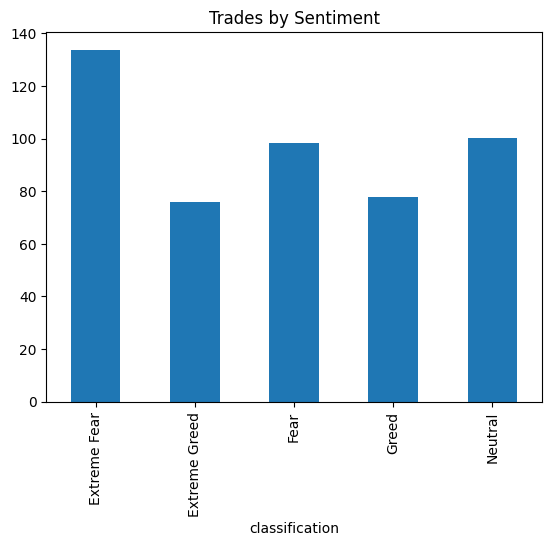

In [28]:
final_df.groupby('classification')['trades'].mean().plot(kind='bar')
plt.title("Trades by Sentiment")
plt.show()

### Insight: Increased Trading Activity During Extreme Fear

- The chart shows that the number of trades is highest during Extreme Fear periods, indicating that traders become more active when the market is highly volatile or uncertain.

- Trading activity is comparatively lower during Greed and Extreme Greed conditions, suggesting that traders are less aggressive when the market is stable or trending positively.

- This pattern highlights that fear-driven markets lead to increased participation, likely due to panic trading or attempts to capitalize on rapid price movements.

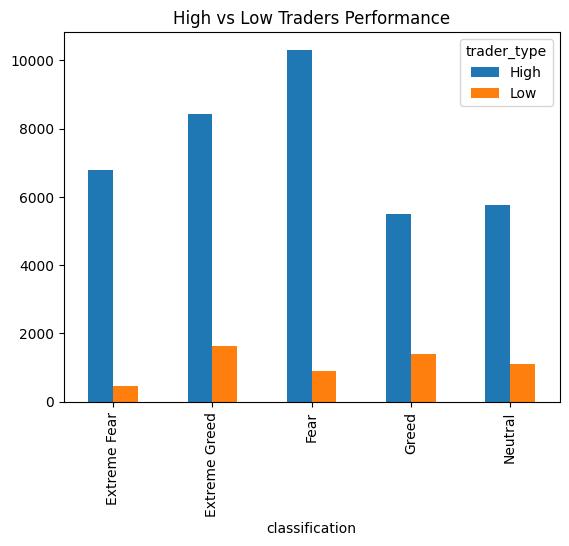

In [29]:
final_df.groupby(['classification','trader_type'])['Closed PnL'].mean().unstack().plot(kind='bar')
plt.title("High vs Low Traders Performance")
plt.show()

### Insight: High-Frequency Traders Significantly Outperform Low-Frequency Traders

- The chart clearly shows that high-frequency traders consistently generate much higher PnL compared to low-frequency traders across all market conditions.

- The performance gap is especially large during Fear and Extreme Greed periods, indicating that active traders are better able to capitalize on both volatile and strongly trending markets.

- In contrast, low-frequency traders show relatively low and stable profits, suggesting limited ability to take advantage of short-term opportunities.

#Part C — “Actionable output”

### Strategy 1: Increase Trading Activity During High Volatility (Fear & Extreme Greed)

Based on the analysis, both Fear and Extreme Greed periods show higher average PnL, indicating strong trading opportunities during volatile or highly trending markets.

- Traders should increase trading frequency during these conditions.
- High-frequency traders particularly benefit the most, as they can capture short-term price movements effectively.
- However, risk management is crucial due to higher downside potential in Fear markets.

---

### Strategy 2: Use Larger Position Sizes Selectively in Fear Markets

Large trades consistently generate higher profits, especially during Fear and Extreme Fear periods where volatility is high.

- Traders can consider increasing position sizes during Fear conditions to maximize returns.
- This strategy should be applied cautiously, as losses are also higher in these periods (high risk–high reward).
- Position sizing should be combined with strict stop-loss mechanisms.

---

### Strategy 3: Avoid Overtrading in Stable (Greed & Neutral) Markets

Greed and Neutral periods show lower PnL and reduced trading effectiveness.

- Traders should reduce trading frequency during these conditions.
- Focus should be on high-confidence trades rather than frequent entries.
- Low-frequency or swing trading strategies may perform better in stable market environments.

---

### Strategy 4: Favor Active Trading Strategies Over Passive Ones

High-frequency traders consistently outperform low-frequency traders across all sentiment conditions.

- Active trading strategies should be preferred, especially during volatile markets.
- Traders should adapt dynamically to market sentiment rather than maintaining a fixed trading approach.